# Grapher

In [1]:
import os
# Ensure LaTeX is found (if using macOS MacTeX)
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.patches as patches

# Set the global LaTeX export rules
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,           # ← change this
    "mathtext.fontset": "cm",
    "pgf.rcfonts": False,
    "axes.unicode_minus": False,
    "pgf.preamble": r"\usepackage{amsmath}",
    "text.latex.preamble": r"\usepackage{amsmath}",  # ← add this
})

def format_textbook_axes(ax, x_limits, y_limits, scale=1.0, x_label='$x$', y_label='$y$'):
    # Scale the font size relative to your base (14)
    fs = 14 * scale
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.set_xticks([])
    ax.set_yticks([])

    # Scale the arrow markers proportionally
    ms = 6 * scale
    ax.plot((1), (0), ls="", marker=">", ms=ms, color="gray",
            transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot((0), (1), ls="", marker="^", ms=ms, color="gray",
            transform=ax.get_xaxis_transform(), clip_on=False)

    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    
    # Calculate the total span of the axes
    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    
    # x-label: placed right after the arrow tip, centered vertically on the y=0 line
    ax.text(x_limits[1] + 0.03 * x_range, 0, x_label, 
            fontsize=fs, fontstyle='italic', ha='left', va='center')
    
    # y-label: placed just above the arrow tip, centered horizontally on the x=0 line
    ax.text(0, y_limits[1] + 0.03 * y_range, y_label, 
            fontsize=fs, fontstyle='italic', ha='center', va='bottom')

def add_textbook_label(ax, x, y, text, scale=1.0, align='center'):
    # Scale both the font and the internal padding of the box
    fs = 14 * scale
    padding = 0.3 * scale
    
    bbox_props = dict(boxstyle=f"square,pad={padding}", fc="#D6EAF8", ec="none")
    
    ax.text(x, y, text, fontsize=fs, family='serif', 
            bbox=bbox_props, ha=align, va='center')


# ── Riemann / integral drawing helper ────────────────────────────────────────
# method: 'left' | 'right' | 'midpoint' | 'inscribed' | 'circumscribed'
#         | 'trapezoid'
# show_area: also fill the exact area under the curve
#
# Colors follow your existing palette; override via rect_color / area_color.
 
def draw_riemann(ax, f, a, b, n,
                 method='inscribed',
                 show_area=True,
                 rect_color='#C9D8F0',   # soft blue – matches your rectangles
                 rect_edge='#212121',
                 area_color='#F2D7D5',   # soft pink – matches your image
                 scale=1.0):
    """
    Draw Riemann-sum rectangles and/or the exact filled area for f on [a, b].
 
    Parameters
    ----------
    ax          : matplotlib Axes
    f           : callable, the function to integrate
    a, b        : float, integration limits
    n           : int, number of sub-intervals
    method      : sampling strategy for rectangle heights
                    'left'          – left endpoint
                    'right'         – right endpoint
                    'midpoint'      – midpoint
                    'inscribed'     – min of f on each sub-interval  (lower sum)
                    'circumscribed' – max of f on each sub-interval  (upper sum)
                    'trapezoid'     – draws trapezoids instead of rectangles
    show_area   : bool, shade the exact area under the curve
    rect_color  : fill colour for rectangles / trapezoids
    rect_edge   : edge colour
    area_color  : fill colour for the exact integral region
    scale       : matches your existing scale parameter (affects linewidths)
    """
    xs = np.linspace(a, b, n + 1)          # sub-interval endpoints
    dx = (b - a) / n
    lw = 1.0 * scale
 
    # ── 1. Exact area (drawn first so rectangles sit on top) ─────────────
    if show_area:
        x_fill = np.linspace(a, b, 500)
        ax.fill_between(x_fill, 0, f(x_fill),
                        color=area_color, alpha=0.55, zorder=1)
 
    # ── 2. Rectangles / trapezoids ────────────────────────────────────────
    for i in range(n):
        x_left  = xs[i]
        x_right = xs[i + 1]
        mid     = (x_left + x_right) / 2.0
 
        if method == 'trapezoid':
            # Draw a filled quadrilateral
            verts = [
                (x_left,  0),
                (x_left,  f(x_left)),
                (x_right, f(x_right)),
                (x_right, 0),
            ]
            trap = plt.Polygon(verts, closed=True,
                               facecolor=rect_color, edgecolor=rect_edge,
                               linewidth=lw, zorder=2)
            ax.add_patch(trap)
 
        else:
            # Determine rectangle height according to method
            if method == 'left':
                height = f(x_left)
            elif method == 'right':
                height = f(x_right)
            elif method == 'midpoint':
                height = f(mid)
            elif method == 'inscribed':
                # Sample f densely on sub-interval and take the minimum
                x_sub  = np.linspace(x_left, x_right, 50)
                height = float(np.min(f(x_sub)))
            elif method == 'circumscribed':
                x_sub  = np.linspace(x_left, x_right, 50)
                height = float(np.max(f(x_sub)))
            else:
                raise ValueError(f"Unknown method '{method}'. Choose from: "
                                 "left, right, midpoint, inscribed, "
                                 "circumscribed, trapezoid.")
 
            rect = patches.Rectangle(
                (x_left, 0), dx, height,
                linewidth=lw, edgecolor=rect_edge,
                facecolor=rect_color, zorder=2
            )
            ax.add_patch(rect)
 
    return ax

def add_textbook_ticks(ax, x_ticks=None, y_ticks=None, x_labels=None, y_labels=None, scale=1.0):
    """Adds cleanly formatted hash marks and LaTeX labels to the central axes."""
    fs = 12 * scale # Slightly smaller than the main 14pt font
    tick_length = 8 * scale
    
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        # Apply custom labels if provided, otherwise just use the numbers formatted as math
        if x_labels is not None:
            ax.set_xticklabels(x_labels, fontsize=fs)
        else:
            ax.set_xticklabels([f'${t}$' for t in x_ticks], fontsize=fs)
            
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        if y_labels is not None:
            ax.set_yticklabels(y_labels, fontsize=fs)
        else:
            ax.set_yticklabels([f'${t}$' for t in y_ticks], fontsize=fs)
            
    # Format the tick marks to look like traditional textbook hash marks crossing the line
    ax.tick_params(axis='both', direction='inout', length=tick_length, width=1*scale, colors='gray')
    
    # Optional: Hide the tick label for '0' if it overlaps the origin crosshair
    labels = ax.get_xticklabels() + ax.get_yticklabels()
    for label in labels:
        if label.get_text() == '$0$' or label.get_text() == '$0.0$':
            label.set_visible(False)

## Chapter 1

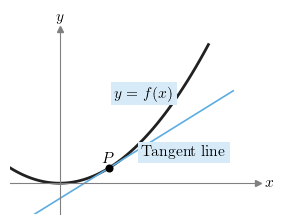

In [45]:
# tangent line problem graph

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply your custom textbook formatting (ADDED scale=s here)
format_textbook_axes(ax, x_limits=[-1, 4], y_limits=[-1, 5], scale=s)

# 3. Plot the math
x = np.linspace(-1, 3, 100)
y = x**2 / 2
x_tangent = np.linspace(-0.5, 3.5, 100)
y_tangent = 1 * (x_tangent - 1) + 0.5 

# Scale the line widths so they don't look overly chunky on a small graph
ax.plot(x, y, color='#212121', linewidth=2.5*s)
ax.plot(x_tangent, y_tangent, color='#5DADE2', linewidth=1.5*s)

# Add the point (SCALED the markersize and fontsize manually here)
ax.plot(1, 0.5, marker='o', color='black', markersize=6*s)
ax.text(0.85, 0.65, '$P$', fontsize=14*s, fontstyle='italic')

# 4. Use your new label function! (ADDED scale=s here)
add_textbook_label(ax, x=1.7, y=2.9, text='$y = f(x)$', scale=s)
add_textbook_label(ax, x=2.5, y=1.0, text='Tangent line', scale=s)

# 5. Save and export
fig.savefig("Ch1/tangent-line-problem.pgf", backend="pgf", bbox_inches='tight')

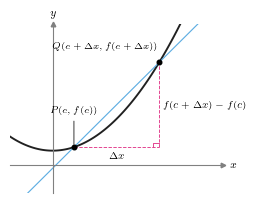

In [46]:
# Difference-quotient graph

s = 0.55

# 1. Create canvas and apply textbook axes (ADDED *s to figsize)
fig, ax = plt.subplots(figsize=(5*s, 4*s))
format_textbook_axes(ax, x_limits=[-1, 4], y_limits=[-1, 5], scale=s)

# 2. Define the math
def f(x): return x**2 / 2 + 0.5
c = 0.5
delta_x = 2.0
x_q = c + delta_x

# Plot the main curve (ADDED *s to linewidth)
x = np.linspace(-1, 3.5, 100)
ax.plot(x, f(x), color='#212121', linewidth=2.5*s)

# Plot the Secant Line (Blue) (ADDED *s to linewidth)
m_sec = (f(x_q) - f(c)) / delta_x
x_sec = np.linspace(-1, 4, 100)
y_sec = m_sec * (x_sec - c) + f(c)
ax.plot(x_sec, y_sec, color='#5DADE2', linewidth=1.5*s)

# 3. Add the structural dashed lines and right angle (Pink/Magenta)
pink_color = '#E13B8A' 
# Horizontal dashed line (ADDED *s to linewidth)
ax.plot([c, x_q], [f(c), f(c)], linestyle='--', color=pink_color, linewidth=1.2*s)
# Vertical dashed line (ADDED *s to linewidth)
ax.plot([x_q, x_q], [f(c), f(x_q)], linestyle='--', color=pink_color, linewidth=1.2*s)

# Right-angle box (ADDED *s to linewidth)
box_size = 0.15
ax.plot([x_q - box_size, x_q - box_size, x_q], 
        [f(c), f(c) + box_size, f(c) + box_size], 
        linestyle='-', color=pink_color, linewidth=1.2*s)

# 4. Points and Annotations
# Point P (ADDED *s to markersize, fontsize, and pointer lw)
ax.plot(c, f(c), marker='o', color='black', markersize=6*s, zorder=5)
ax.annotate('$P(c, f(c))$', xy=(c, f(c)), xytext=(c, f(c) + 1.2),
            arrowprops=dict(arrowstyle='-', color='black', lw=1*s), 
            fontsize=12*s, ha='center')

# Point Q (ADDED *s to markersize and fontsize)
ax.plot(x_q, f(x_q), marker='o', color='black', markersize=6*s, zorder=5)
ax.annotate('$Q(c+\\Delta x, f(c+\\Delta x))$', xy=(x_q, f(x_q)), xytext=(x_q, f(x_q) + 0.5),
            fontsize=12*s, ha='right')

# Labels for Delta x and Delta y (ADDED *s to fontsize)
ax.text(c + delta_x/2, f(c) - 0.4, '$\\Delta x$', fontsize=13*s, ha='center')
ax.text(x_q + 0.1, f(c) + (f(x_q)-f(c))/2, '$f(c+\\Delta x) - f(c)$', fontsize=13*s, va='center')

# 5. Save and export
fig.savefig("Ch1/difference-quotient.pgf", backend="pgf", bbox_inches='tight')
plt.show()

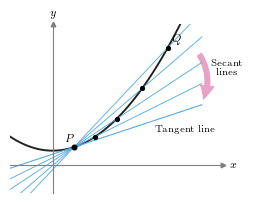

In [47]:
# Secant Limit Graph

import matplotlib.patches as patches

s = 0.55

# 1. Create canvas and apply textbook axes (ADDED *s to figsize)
fig, ax = plt.subplots(figsize=(5*s, 4*s))
format_textbook_axes(ax, x_limits=[-1, 4], y_limits=[-1, 5], scale=s)

# 2. Define the math
def f(x): return x**2 / 2 + 0.5
c = 0.5
x = np.linspace(-1, 3.5, 100)

# Plot the main curve (ADDED *s to linewidth)
ax.plot(x, f(x), color='#212121', linewidth=2.5*s)

# Plot the Tangent Line (Bottom blue line) (ADDED *s to linewidth)
m_tan = c 
y_tan = m_tan * (x - c) + f(c)
ax.plot(x, y_tan, color='#5DADE2', linewidth=1.5*s)

# 3. Draw multiple Secant lines using a loop
delta_x_values = [2.2, 1.6, 1.0, 0.5]

for dx in delta_x_values:
    x_q = c + dx
    m_sec = (f(x_q) - f(c)) / dx
    y_sec = m_sec * (x - c) + f(c)
    
    # Draw the secant line (ADDED *s to linewidth)
    ax.plot(x, y_sec, color='#5DADE2', linewidth=1.2*s)
    # Draw the point Q for this secant line (ADDED *s to markersize)
    ax.plot(x_q, f(x_q), marker='o', color='black', markersize=5*s, zorder=5)

# Point P (drawn last so it sits on top) (ADDED *s to markersize and fontsize)
ax.plot(c, f(c), marker='o', color='black', markersize=6*s, zorder=5)
ax.text(c - 0.2, f(c) + 0.2, '$P$', fontsize=14*s, fontstyle='italic')
ax.text(c + 2.2 + 0.1, f(c + 2.2) + 0.2, '$Q$', fontsize=14*s, fontstyle='italic')

# 4. Add labels (ADDED *s to fontsize)
ax.text(2.4, 1.2, 'Tangent line', fontsize=12*s, family='serif')
ax.text(4.1, 3.2, 'Secant\nlines', fontsize=12*s, family='serif', ha='center')

# 5. Create the large curved pink arrow (ADDED *s to mutation_scale)
curved_arrow = patches.FancyArrowPatch(
    (3.4, 4.0),    
    (3.5, 2.2),    
    connectionstyle="arc3,rad=-0.3", 
    color='#E8A2C7', 
    mutation_scale=40*s,  # This dictates the size of the arrowhead itself
    linewidth=0,
    zorder=1
)
ax.add_patch(curved_arrow)

# 6. Save and export
fig.savefig("Ch1/secant-limit.pgf", backend="pgf", bbox_inches='tight')
plt.show()

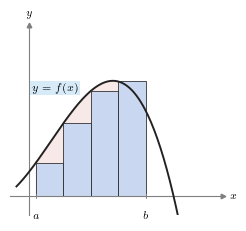

In [48]:
# ── Example: inscribed rectangles + exact area (matches your image) ──────────
if __name__ == '__main__':
 
    s = 0.55   # your scale factor
 
    # Define a function that looks like the one in the reference image:
    # rises steeply, has a gentle wave in the middle, then rises again.
    def f(x):
        return -0.7* x**3 + 0.7 * x**2 + 1.7 * x + .5
 
    a, b = 0.1, 1.8    # integration limits  → will be labelled a and b
    n    = 4           # number of rectangles
 
    fig, ax = plt.subplots(figsize=(5 * s, 4.5 * s))
    format_textbook_axes(ax, x_limits=[-0.3, 3],
                             y_limits=[-0.4, 3.5], scale=s)
 
    # Draw rectangles + shaded area
    draw_riemann(ax, f, a, b, n,
                 method='left',
                 show_area=True, # shows the exact area under the curve
                 scale=s)
 
    # Plot the curve on top
    x_curve = np.linspace(-0.2, 6.2, 400)
    ax.plot(x_curve, f(x_curve), color='#212121', linewidth=2.5 * s, zorder=3)
 
    # a and b tick marks + labels
    tick_h = 0.08 * s
    for val, lbl in [(a, '$a$'), (b, '$b$')]:
        ax.plot([val, val], [-tick_h, tick_h], color='gray',
                linewidth=1.2 * s, zorder=4)
        ax.text(val, -0.32, lbl, fontsize=14 * s,
                fontstyle='italic', ha='center', va='top')
 
    # Curve label
    add_textbook_label(ax, x=0.4, y=2.2, text='$y = f(x)$', scale=s)
 
    fig.savefig("Ch1/area-problem-n4.pgf", backend="pgf", bbox_inches='tight')
    plt.show()

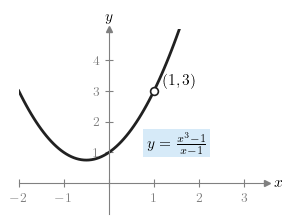

In [49]:
# hole in (x**3 - 1) / (x - 1)

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-2, 3.5], y_limits=[-1, 5], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-2, -1, 0, 1, 2, 3], y_ticks=[1, 2, 3, 4], scale=s)

# 3. Plot the math
x = np.linspace(-2, 3.5, 100)
y = x**2 + x + 1 

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# Add the OPEN CIRCLE (hole)
ax.plot(1, 3, marker='o', markerfacecolor='white', markeredgecolor='#212121', 
        markersize=7*s, markeredgewidth=1.5*s, zorder=5)
        
ax.text(1.2, 3.2, '$(1, 3)$', fontsize=14*s, fontstyle='italic')

# 4. Use your label function
add_textbook_label(ax, x=1.5, y=1.3, text='$y = \\frac{x^3 - 1}{x - 1}$', scale=s)

# 5. Save and export
fig.savefig("Ch1/hole1.pgf", backend="pgf", bbox_inches='tight')

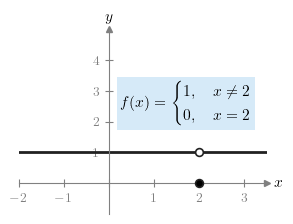

In [50]:
# hole in horizontal line

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-2, 3.5], y_limits=[-1, 5], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-2, -1, 0, 1, 2, 3], y_ticks=[1, 2, 3, 4], scale=s)

# 3. Plot the math
x = np.linspace(-2, 3.5, 100)
y = np.ones_like(x)
y[np.isclose(x, 2)] = np.nan

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# Add the OPEN CIRCLE (hole)
ax.plot(2, 1, marker='o', markerfacecolor='white', markeredgecolor='#212121', 
        markersize=7*s, markeredgewidth=1.5*s, zorder=5)
        

# Add the CLOSED CIRCLE (hole)
ax.plot(2, 0, marker='o', markerfacecolor='black', markeredgecolor='#212121', 
        markersize=7*s, markeredgewidth=1.5*s, zorder=5)


# 4. Use your label function
text = r'$f(x) = \begin{cases} 1, \quad x \neq 2 \\ 0, \quad x = 2 \end{cases}$'
add_textbook_label(ax, x=1.7, y=2.6, text=text, scale=s)

# 5. Save and export
fig.savefig("Ch1/hole2.pgf", backend="pgf", bbox_inches='tight')

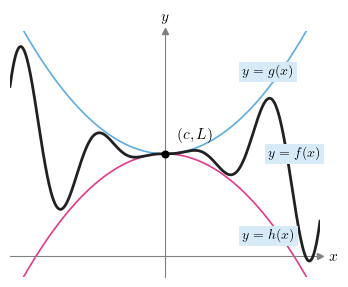

In [51]:
s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting 
format_textbook_axes(ax, x_limits=[-1.2, 1.2], y_limits=[-.2, 2.2], scale=s)

# 3. Define the math
# We use x^2 * sin(10x) to simulate the squeeze without infinite complexity at x=0
x = np.linspace(-1.2, 1.2, 500)
g = x**2 + 1                 # Upper bound
h = -x**2 + 1                # Lower bound
f = .85 * x**2 * np.sin(10 * x) + 1 # Squeezed function

# 4. Plot the curves
# We plot the bounds in lighter colors and thinner lines, and the main function bold
ax.plot(x, g, color='#5DADE2', linewidth=1.5*s, zorder=2) # Blue
ax.plot(x, h, color='#E13B8A', linewidth=1.5*s, zorder=2) # Pink
ax.plot(x, f, color='#212121', linewidth=2.5*s, zorder=3) # Black

# 5. Add the squeeze point P at c=0, L=1
ax.plot(0, 1, marker='o', color='black', markersize=6*s, zorder=5)
ax.text(0.1, 1.15, '$(c, L)$', fontsize=14*s, fontstyle='italic')

# 6. Add textbook labels
add_textbook_label(ax, x=0.8, y=1.8, text='$y = g(x)$', scale=s*0.9)
add_textbook_label(ax, x=0.8, y=0.2, text='$y = h(x)$', scale=s*0.9)
add_textbook_label(ax, x=1.0, y=1.0, text='$y = f(x)$', scale=s*0.9)

# 7. Save and export
fig.savefig("Ch1/squeeze_theorem.pgf", backend="pgf", bbox_inches='tight')
plt.show()

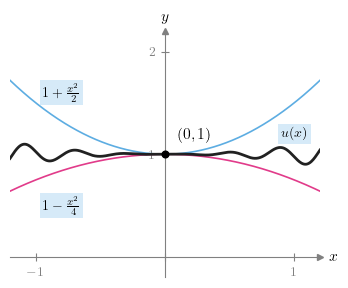

In [52]:
import matplotlib.pyplot as plt
import numpy as np

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting 
format_textbook_axes(ax, x_limits=[-1.2, 1.2], y_limits=[-.2, 2.2], scale=s)
add_textbook_ticks(ax, x_ticks=[-1, 0, 1], y_ticks=[1, 2], scale=s)

# 3. Define the math
x = np.linspace(-1.2, 1.2, 500)
g = 1 + x**2/2                 # Upper bound
h = 1 - x**2/4                 # Lower bound
f = 1 + x**2/12 * np.sin(16 * x) # Squeezed function

# 4. Plot the curves
# We plot the bounds in lighter colors and thinner lines, and the main function bold
ax.plot(x, g, color='#5DADE2', linewidth=1.5*s, zorder=2) # Blue
ax.plot(x, h, color='#E13B8A', linewidth=1.5*s, zorder=2) # Pink
ax.plot(x, f, color='#212121', linewidth=2.5*s, zorder=3) # Black

# 5. Add the squeeze point P at c=0, L=1
ax.plot(0, 1, marker='o', color='black', markersize=6*s, zorder=5)
ax.text(0.1, 1.15, '$(0, 1)$', fontsize=14*s, fontstyle='italic')

# 6. Add textbook labels
# Using 'r' for raw strings on the fractions to prevent LaTeX crashes!
add_textbook_label(ax, x=-0.8, y=1.6, text=r'$1 + \frac{x^2}{2}$', scale=s*0.9)  # Upper bound
add_textbook_label(ax, x=-0.8, y=0.5, text=r'$1 - \frac{x^2}{4}$', scale=s*0.9)  # Lower bound
add_textbook_label(ax, x=1, y=1.2, text='$u(x)$', scale=s*0.9)                 # Squeezed function

# 7. Save and export
fig.savefig("Ch1/squeeze_theorem_example1.pgf", backend="pgf", bbox_inches='tight')
plt.show()

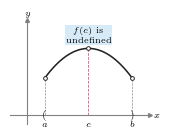

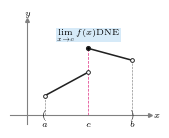

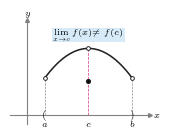

In [53]:
# A smaller scale to fit three graphs across a standard LaTeX page
s = 0.45 

# The open bounds on the positive x-axis
a = 0.5
b = 3.0
c = 1.75 

# ==========================================
# GRAPH 1: f(c) is not defined (Hole)
# ==========================================
fig1, ax1 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax1, x_limits=[-0.5, 3.5], y_limits=[-0.5, 5], scale=s)

x1 = np.linspace(a, b, 100)
y1 = -(x1 - c)**2 + 3.5

# Main curve and dashed drop-lines
ax1.plot(x1, y1, color='#212121', linewidth=2.5*s, zorder=2)
ax1.plot([c, c], [0, 3.5], linestyle='--', color='#E13B8A', linewidth=1.2*s, zorder=1)
ax1.plot([a, a], [0, -(a - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)
ax1.plot([b, b], [0, -(b - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)

# Open circles at bounds a and b
ax1.plot(a, -(a - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax1.plot(b, -(b - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Open Circle at (c, L)
ax1.plot(c, 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Axis labels AND Parentheses on the axis
ax1.text(a, 0, '$($', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax1.text(b, 0, '$)$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax1.text(a, -0.3, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax1.text(b, -0.3, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax1.text(c, -0.3, r'$c$', fontsize=14*s, fontstyle='italic', ha='center', va='top')

# Description Label (Stacked)
text1 = r'$f(c)$ is' + '\n' + 'undefined'
add_textbook_label(ax1, x=1.75, y=4.2, text=text1, scale=s)

fig1.savefig("Ch1/discontinuity_undefined.pgf", backend="pgf", bbox_inches='tight')


# ==========================================
# GRAPH 2: Limit DNE at x=c (Jump)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax2, x_limits=[-0.5, 3.5], y_limits=[-0.5, 5], scale=s)

x2_left = np.linspace(a, c, 100)
y2_left = x2_left + 0.5
x2_right = np.linspace(c, b, 100)
y2_right = -0.5 * (x2_right - c) + 3.5

# Main curves and dashed drop-lines
ax2.plot(x2_left, y2_left, color='#212121', linewidth=2.5*s, zorder=2)
ax2.plot(x2_right, y2_right, color='#212121', linewidth=2.5*s, zorder=2)
ax2.plot([c, c], [0, 3.5], linestyle='--', color='#E13B8A', linewidth=1.2*s, zorder=1)
ax2.plot([a, a], [0, a + 0.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)
ax2.plot([b, b], [0, -0.5 * (b - c) + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)

# Open circles at bounds a and b
ax2.plot(a, a + 0.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax2.plot(b, -0.5 * (b - c) + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Left Hole, Right Dot at c
ax2.plot(c, c + 0.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax2.plot(c, 3.5, marker='o', markerfacecolor='black', markeredgecolor='#212121', markersize=6*s, zorder=5)

# Axis labels AND Parentheses on the axis
ax2.text(a, 0, '$($', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax2.text(b, 0, '$)$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax2.text(a, -0.3, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax2.text(b, -0.3, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax2.text(c, -0.3, r'$c$', fontsize=14*s, fontstyle='italic', ha='center', va='top')

# Description Label
# \limits forces the x->c underneath the lim, saving horizontal space!
text2 = r'$\lim\limits_{x \to c} f(x)$' + 'DNE'
add_textbook_label(ax2, x=1.75, y=4.2, text=text2, scale=s)

fig2.savefig("Ch1/discontinuity_dne.pgf", backend="pgf", bbox_inches='tight')


# ==========================================
# GRAPH 3: Limit exists, but != f(c) (Displaced)
# ==========================================
fig3, ax3 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax3, x_limits=[-0.5, 3.5], y_limits=[-0.5, 5], scale=s)

x3 = np.linspace(a, b, 100)
y3 = -(x3 - c)**2 + 3.5

# Main curve and dashed drop-lines
ax3.plot(x3, y3, color='#212121', linewidth=2.5*s, zorder=2)
ax3.plot([c, c], [0, 3.5], linestyle='--', color='#E13B8A', linewidth=1.2*s, zorder=1)
ax3.plot([a, a], [0, -(a - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)
ax3.plot([b, b], [0, -(b - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)

# Open circles at bounds a and b
ax3.plot(a, -(a - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax3.plot(b, -(b - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Open Circle at the limit, Solid Dot at the actual value
ax3.plot(c, 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax3.plot(c, 1.8, marker='o', markerfacecolor='black', markeredgecolor='#212121', markersize=6*s, zorder=5)

# Axis labels AND Parentheses on the axis
ax3.text(a, 0, '$($', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax3.text(b, 0, '$)$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax3.text(a, -0.3, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax3.text(b, -0.3, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax3.text(c, -0.3, r'$c$', fontsize=14*s, fontstyle='italic', ha='center', va='top')

# Description Label
text3 = r'$\lim\limits_{x \to c} f(x)$' + r'$\neq f(c)$'
add_textbook_label(ax3, x=1.75, y=4.2, text=text3, scale=s)

fig3.savefig("Ch1/discontinuity_displaced.pgf", backend="pgf", bbox_inches='tight')
plt.show()

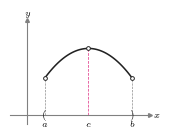

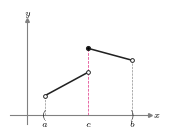

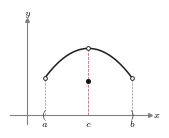

In [54]:
# A smaller scale to fit three graphs across a standard LaTeX page
s = 0.45 

# The open bounds on the positive x-axis
a = 0.5
b = 3.0
c = 1.75 

# ==========================================
# GRAPH 1: f(c) is not defined (Hole)
# ==========================================
fig1, ax1 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax1, x_limits=[-0.5, 3.5], y_limits=[-0.5, 5], scale=s)

x1 = np.linspace(a, b, 100)
y1 = -(x1 - c)**2 + 3.5

# Main curve and dashed drop-lines
ax1.plot(x1, y1, color='#212121', linewidth=2.5*s, zorder=2)
ax1.plot([c, c], [0, 3.5], linestyle='--', color='#E13B8A', linewidth=1.2*s, zorder=1)
ax1.plot([a, a], [0, -(a - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)
ax1.plot([b, b], [0, -(b - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)

# Open circles at bounds a and b
ax1.plot(a, -(a - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax1.plot(b, -(b - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Open Circle at (c, L)
ax1.plot(c, 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Axis labels AND Parentheses on the axis
ax1.text(a, 0, '$($', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax1.text(b, 0, '$)$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax1.text(a, -0.3, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax1.text(b, -0.3, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax1.text(c, -0.3, r'$c$', fontsize=14*s, fontstyle='italic', ha='center', va='top')


fig1.savefig("Ch1/removable_discontinuity.pgf", backend="pgf", bbox_inches='tight')


# ==========================================
# GRAPH 2: Limit DNE at x=c (Jump)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax2, x_limits=[-0.5, 3.5], y_limits=[-0.5, 5], scale=s)

x2_left = np.linspace(a, c, 100)
y2_left = x2_left + 0.5
x2_right = np.linspace(c, b, 100)
y2_right = -0.5 * (x2_right - c) + 3.5

# Main curves and dashed drop-lines
ax2.plot(x2_left, y2_left, color='#212121', linewidth=2.5*s, zorder=2)
ax2.plot(x2_right, y2_right, color='#212121', linewidth=2.5*s, zorder=2)
ax2.plot([c, c], [0, 3.5], linestyle='--', color='#E13B8A', linewidth=1.2*s, zorder=1)
ax2.plot([a, a], [0, a + 0.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)
ax2.plot([b, b], [0, -0.5 * (b - c) + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)

# Open circles at bounds a and b
ax2.plot(a, a + 0.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax2.plot(b, -0.5 * (b - c) + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Left Hole, Right Dot at c
ax2.plot(c, c + 0.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax2.plot(c, 3.5, marker='o', markerfacecolor='black', markeredgecolor='#212121', markersize=6*s, zorder=5)

# Axis labels AND Parentheses on the axis
ax2.text(a, 0, '$($', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax2.text(b, 0, '$)$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax2.text(a, -0.3, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax2.text(b, -0.3, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax2.text(c, -0.3, r'$c$', fontsize=14*s, fontstyle='italic', ha='center', va='top')


fig2.savefig("Ch1/nonremovable_discontinuity.pgf", backend="pgf", bbox_inches='tight')


# ==========================================
# GRAPH 3: Limit exists, but != f(c) (Displaced)
# ==========================================
fig3, ax3 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax3, x_limits=[-0.5, 3.5], y_limits=[-0.5, 5], scale=s)

x3 = np.linspace(a, b, 100)
y3 = -(x3 - c)**2 + 3.5

# Main curve and dashed drop-lines
ax3.plot(x3, y3, color='#212121', linewidth=2.5*s, zorder=2)
ax3.plot([c, c], [0, 3.5], linestyle='--', color='#E13B8A', linewidth=1.2*s, zorder=1)
ax3.plot([a, a], [0, -(a - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)
ax3.plot([b, b], [0, -(b - c)**2 + 3.5], linestyle='--', color='gray', linewidth=1*s, zorder=1)

# Open circles at bounds a and b
ax3.plot(a, -(a - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax3.plot(b, -(b - c)**2 + 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)

# Open Circle at the limit, Solid Dot at the actual value
ax3.plot(c, 3.5, marker='o', markerfacecolor='white', markeredgecolor='#212121', markersize=6*s, markeredgewidth=1.5*s, zorder=5)
ax3.plot(c, 1.8, marker='o', markerfacecolor='black', markeredgecolor='#212121', markersize=6*s, zorder=5)

# Axis labels AND Parentheses on the axis
ax3.text(a, 0, '$($', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax3.text(b, 0, '$)$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax3.text(a, -0.3, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax3.text(b, -0.3, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax3.text(c, -0.3, r'$c$', fontsize=14*s, fontstyle='italic', ha='center', va='top')


fig3.savefig("Ch1/removable_discontinuity2.pgf", backend="pgf", bbox_inches='tight')
plt.show()

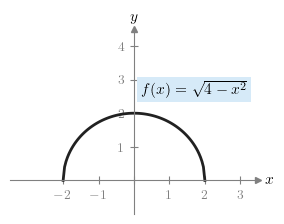

In [55]:
# limit of sqrt{4-x^2} as x->-2

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-3.5, 3.5], y_limits=[-1, 4.5], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-2, -1, 0, 1, 2, 3], y_ticks=[1, 2, 3, 4], scale=s)

# 3. Plot the math
x = np.linspace(-2, 2, 100)
y = np.sqrt(4 - x**2)

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# # Add the OPEN CIRCLE (hole)
# ax.plot(1, 3, marker='o', markerfacecolor='white', markeredgecolor='#212121', 
#         markersize=7*s, markeredgewidth=1.5*s, zorder=5)
        
# ax.text(-1.8, 3.2, '$(-2, 2)$', fontsize=14*s, fontstyle='italic')

# 4. Use your label function
add_textbook_label(ax, x=1.7, y=2.7, text='$f(x) = \sqrt{4-x^2}$', scale=s)

# 5. Save and export
fig.savefig("Ch1/limit_of_root.pgf", backend="pgf", bbox_inches='tight')

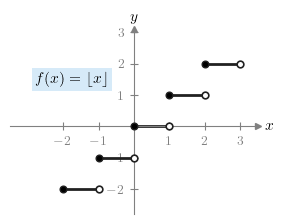

In [56]:
# step function of floor(x) from -2 to 3

s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-3.5, 3.5], y_limits=[-2.8, 3.1], scale=s)
add_textbook_ticks(ax,
                   x_ticks=[-2, -1, 0, 1, 2, 3],
                   y_ticks=[-2, -1, 0, 1, 2, 3],
                   scale=s)

# 3. Plot the math
x = np.linspace(-2, 3, 1000)
y = np.floor(x)

# Draw the step function without vertical bars
for jump in range(-2, 3):
    x_seg = np.linspace(jump, jump + 1, 100)
    y_seg = np.full_like(x_seg, jump)
    ax.plot(x_seg, y_seg, color='#212121', linewidth=2.5*s, zorder=2)

# Add closed circles on the left endpoints
# and open circles on the right endpoints
for jump in range(-2, 3):
    # Closed left endpoint
    ax.plot(jump, jump,
            marker='o',
            markerfacecolor='black',
            markeredgecolor='#212121',
            markersize=6*s,
            zorder=5)

    # Open right endpoint
    ax.plot(jump + 1, jump,
            marker='o',
            markerfacecolor='white',
            markeredgecolor='#212121',
            markersize=6*s,
            markeredgewidth=1.5*s,
            zorder=5)

# 4. Use your label function
add_textbook_label(ax,
                   x=-1.75,
                   y=1.5,
                   text=r'$f(x)=\lfloor x\rfloor$',
                   scale=s)

# 5. Save and export
fig.savefig("Ch1/floor_function.pgf", backend="pgf", bbox_inches='tight')

plt.show()

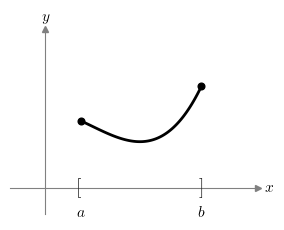

In [57]:
# continuity on a closed interval [a, b] for some generic function without discontinuities
s = 0.8
# 1. Create a blank canvas  
fig, ax = plt.subplots(figsize=(4*s, 3*s))
# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-.5, 3], y_limits=[-.5, 3.1], scale=s)


# 4. Plot the math
x = np.linspace(.5, 2.2, 100)
y = 0.5 * x**3 - x**2 + 1.5
ax.plot(x, y, color='black', linewidth=2)
# 5. Add the closed circles at the endpoints
ax.plot(0.5, 0.5 * 0.5**3 - 0.5**2 + 1.5, marker='o', color='black', markersize=6*s, zorder=5)
ax.plot(2.2, 0.5 * 2.2**3 - 2.2**2 + 1.5, marker='o', color='black', markersize=6*s, zorder=5)

# 6. add axes labels with brackets at generic points a and b
ax.text(0.5, 0, '$[$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax.text(2.2, 0, '$]$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax.text(0.5, -0.35, '$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax.text(2.2, -0.35, '$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')

# 7. Save and export
fig.savefig("Ch1/def_of_continuity.pgf", backend="pgf", bbox_inches='tight')

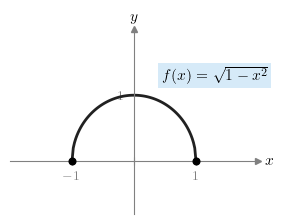

In [58]:
# continuity of sqrt{1-x^2}

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-2, 2], y_limits=[-.8, 2], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-1, 0, 1], y_ticks=[1], scale=s)

# 3. Plot the math
x = np.linspace(-1, 1, 100)
y = np.sqrt(1 - x**2)

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# add closed circles at the endpoints to show the function is defined there
ax.plot(-1, 0, marker='o', color='black', markersize=6*s, zorder=5)
ax.plot(1, 0, marker='o', color='black', markersize=6*s, zorder=5)

# 4. Use your label function
add_textbook_label(ax, x=1.3, y=1.3, text='$f(x) = \sqrt{1-x^2}$', scale=s)

# 5. Save and export
fig.savefig("Ch1/continuity_of_root.pgf", backend="pgf", bbox_inches='tight')

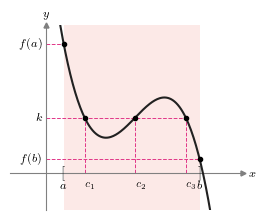

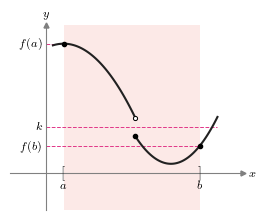

In [59]:
s = 0.6
pink_color = '#E13B8A'
bg_pink = '#FADBD8'

# ==========================================
# GRAPH 1: IVT Continuous
# ==========================================
fig1, ax1 = plt.subplots(figsize=(5*s, 4*s))
format_textbook_axes(ax1, x_limits=[-1, 5.5], y_limits=[-2, 8], scale=s)

a, b = 0.5, 4.3

# Define the cubic function
def f_cont(x): return -(x-2.5)**3 + 2*(x-2.5) + 3

# Add Shaded Pink Interval
ax1.axvspan(a, b, facecolor=bg_pink, alpha=0.6, zorder=0)

# Brackets and Axis Labels
ax1.text(a, 0, '$[$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax1.text(b, 0, '$]$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax1.text(a, -0.4, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax1.text(b, -0.4, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')

# Plot the main continuous curve
x_cont = np.linspace(0.2, 4.8, 200)
ax1.plot(x_cont, f_cont(x_cont), color='#212121', linewidth=2.5*s, zorder=3)

# Endpoints
ax1.plot(a, f_cont(a), marker='o', color='black', markersize=5*s, zorder=5)
ax1.plot(b, f_cont(b), marker='o', color='black', markersize=5*s, zorder=5)

# Target line y = k and intersection points c1, c2, c3
k = 3
c1, c2, c3 = 2.5 - np.sqrt(2), 2.5, 2.5 + np.sqrt(2)

# Horizontal dashed lines (f(a), k, f(b))
ax1.plot([0, a], [f_cont(a), f_cont(a)], linestyle='--', color=pink_color, linewidth=1.2*s, zorder=2)
ax1.text(-0.1, f_cont(a), r'$f(a)$', fontsize=14*s, fontstyle='italic', ha='right', va='center')

ax1.plot([0, b], [f_cont(b), f_cont(b)], linestyle='--', color=pink_color, linewidth=1.2*s, zorder=2)
ax1.text(-0.1, f_cont(b), r'$f(b)$', fontsize=14*s, fontstyle='italic', ha='right', va='center')

ax1.plot([0, c3], [k, k], linestyle='--', color=pink_color, linewidth=1.2*s, zorder=2)
ax1.text(-0.1, k, r'$k$', fontsize=14*s, fontstyle='italic', ha='right', va='center')

# Vertical dashed lines and point markers for c
for c_val, label in zip([c1, c2, c3], ['c_1', 'c_2', 'c_3']):
    ax1.plot([c_val, c_val], [0, k], linestyle='--', color=pink_color, linewidth=1.2*s, zorder=2)
    ax1.plot(c_val, k, marker='o', color='black', markersize=5*s, zorder=5)
    ax1.text(c_val + 0.15, -0.4, f'${label}$', fontsize=12*s, fontstyle='italic', ha='center', va='top')

fig1.savefig("Ch1/ivt_continuous.pgf", backend="pgf", bbox_inches='tight')


# ==========================================
# GRAPH 2: IVT Discontinuous (Jump)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(5*s, 4*s))
format_textbook_axes(ax2, x_limits=[-1, 5.5], y_limits=[-2, 8], scale=s)

# Add Shaded Pink Interval
ax2.axvspan(a, b, facecolor=bg_pink, alpha=0.6, zorder=0)

# Brackets and Axis Labels
ax2.text(a, 0, '$[$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax2.text(b, 0, '$]$', fontsize=18*s, ha='center', va='center', color='#212121', zorder=6)
ax2.text(a, -0.4, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
ax2.text(b, -0.4, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')

# Define piecewise math logic
def f_left(x): return 7 - (x-0.5)**2
def f_right(x): return 0.5 + 1.5*(x-3.5)**2

x_left = np.linspace(0.2, 2.5, 100)
x_right = np.linspace(2.5, 4.8, 100)

# Plot main curves
ax2.plot(x_left, f_left(x_left), color='#212121', linewidth=2.5*s, zorder=3)
ax2.plot(x_right, f_right(x_right), color='#212121', linewidth=2.5*s, zorder=3)

# Endpoints
ax2.plot(a, f_left(a), marker='o', color='black', markersize=5*s, zorder=5)
ax2.plot(b, f_right(b), marker='o', color='black', markersize=5*s, zorder=5)

# Jump Discontinuity explicitly marked at x=2.5
ax2.plot(2.5, f_left(2.5), marker='o', markerfacecolor='white', markeredgecolor='black', markersize=5*s, markeredgewidth=1.2*s, zorder=5)
ax2.plot(2.5, f_right(2.5), marker='o', color='black', markersize=5*s, zorder=5)

# Horizontal dashed lines
k_disc = 2.5
ax2.plot([0, 4.8], [k_disc, k_disc], linestyle='--', color=pink_color, linewidth=1.2*s, zorder=2)
ax2.text(-0.1, k_disc, r'$k$', fontsize=14*s, fontstyle='italic', ha='right', va='center')

ax2.plot([0, a], [f_left(a), f_left(a)], linestyle='--', color=pink_color, linewidth=1.2*s, zorder=2)
ax2.text(-0.1, f_left(a), r'$f(a)$', fontsize=14*s, fontstyle='italic', ha='right', va='center')

ax2.plot([0, b], [f_right(b), f_right(b)], linestyle='--', color=pink_color, linewidth=1.2*s, zorder=2)
ax2.text(-0.1, f_right(b), r'$f(b)$', fontsize=14*s, fontstyle='italic', ha='right', va='center')

fig2.savefig("Ch1/ivt_discontinuous.pgf", backend="pgf", bbox_inches='tight')
plt.show()

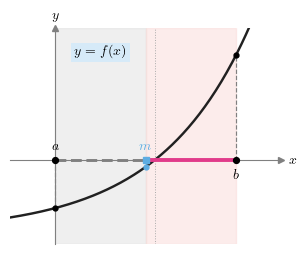

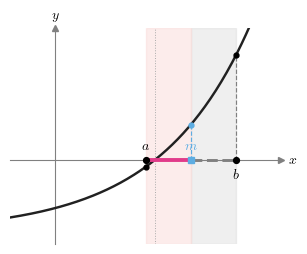

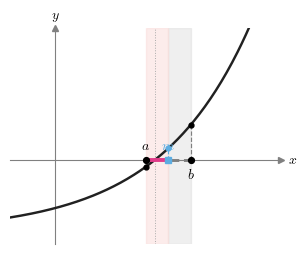

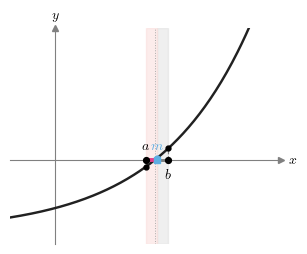

In [60]:
s = 0.7
root = np.log(3)

def f(x): return np.exp(x) - 3

# Run bisection iterations and record exact states
def bisect_steps(a, b, n):
    steps = []
    for _ in range(n):
        m = (a + b) / 2
        # Dynamically determine which half is kept based on the root location
        if f(a) * f(m) < 0:
            kept = (a, m)
            discarded = (m, b)
            next_a, next_b = a, m
        else:
            kept = (m, b)
            discarded = (a, m)
            next_a, next_b = m, b
            
        steps.append((a, b, m, kept, discarded))
        a, b = next_a, next_b
    return steps

steps = bisect_steps(0.0, 2.0, 4) 
x_vals = np.linspace(-0.5, 2.5, 200)

for i, (a, b, m, kept, discarded) in enumerate(steps):
    # Create a fresh canvas for each step
    fig, ax = plt.subplots(figsize=(5*s, 4*s))
    format_textbook_axes(ax, x_limits=[-0.5, 2.5], y_limits=[-3.5, 5.5], scale=s)

    # Shaded regions: only highlight the active [a, b] interval
    ax.axvspan(discarded[0], discarded[1], color='#CCCCCC', alpha=0.3, zorder=0) # Discarded half
    ax.axvspan(kept[0], kept[1], color='#FADBD8', alpha=0.5, zorder=0)           # Retained half

    # True root reference
    ax.axvline(root, color='#AAAAAA', linewidth=1.0*s, linestyle=':', zorder=1)

    # Main Curve
    ax.plot(x_vals, f(x_vals), color='#212121', linewidth=2.5*s, zorder=3)

    # x-axis interval highlighting
    ax.plot([discarded[0], discarded[1]], [0, 0], color='gray', linewidth=3*s, linestyle='--', zorder=4)
    ax.plot([kept[0], kept[1]], [0, 0], color='#E13B8A', linewidth=4*s, zorder=4)

    # Vertical dashed drop lines
    for x, col in [(a, 'gray'), (b, 'gray'), (m, '#5DADE2')]:
        ax.plot([x, x], [0, f(x)], linestyle='--', color=col, linewidth=1.2*s, zorder=2)

    # Points on x-axis and curve
    for x, col, mk in [(a, 'black', 'o'), (b, 'black', 'o'), (m, '#5DADE2', 's')]:
        ax.plot(x, 0, marker=mk, color=col, markersize=6*s, zorder=5)
        ax.plot(x, f(x), marker='o', color=col, markersize=5*s, zorder=5)

    # Labels (Dynamically shifted vertically to prevent crowding on the tight axis)
    ax.text(a, 0.3, r'$a$', fontsize=14*s, fontstyle='italic', ha='center', va='bottom')
    ax.text(b, -0.4, r'$b$', fontsize=14*s, fontstyle='italic', ha='center', va='top')
    ax.text(m, 0.3, r'$m$', fontsize=14*s, fontstyle='italic', color='#5DADE2', ha='center', va='bottom')

    # Add the function label only on the first step for cleanliness
    if i == 0:
        add_textbook_label(ax, x=0.5, y=4.5, text=r'$y = f(x)$', scale=s)

    # Save individual file and close canvas to free memory
    filename = f"Ch1/bisection_step_{i+1}.pgf"
    fig.savefig(filename, backend="pgf", bbox_inches='tight')

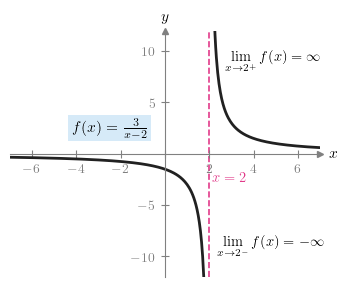

In [61]:
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-7, 7], y_limits=[-12, 12], scale=s)
add_textbook_ticks(ax, x_ticks=[-6, -4, -2, 0, 2, 4, 6], y_ticks=[-10, -5, 5, 10], scale=s)

# 3. Plot the math
x_left = np.linspace(-8, 1.95, 200)
# Use np.clip to cap the maximum values so the PGF/LaTeX backend doesn't crash!
y_left = np.clip(3 / (x_left - 2), -50, 50) 

x_right = np.linspace(2.05, 8, 200)
y_right = np.clip(3 / (x_right - 2), -50, 50)

# Plot both sides
ax.plot(x_left, y_left, color='#212121', linewidth=2.5*s, zorder=2)
ax.plot(x_right, y_right, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Add vertical asymptote at x=2
ax.axvline(2, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# 5. Add labels 
# Asymptote and Function labels
ax.text(2.1, -3, r'$x=2$', color='#E13B8A', fontsize=13*s, ha='left', va='bottom')
add_textbook_label(ax, x=-2.5, y=2.5, text=r'$f(x) = \frac{3}{x-2}$', scale=s)

# --- NEW: Limit Statements ---
# Using \limits to stack the 'x -> 2' neatly under the 'lim'
lim_left = r'$\lim\limits_{x \to 2^-} f(x) = -\infty$'
ax.text(7.2, -9, lim_left, fontsize=13*s, ha='right', va='center')

lim_right = r'$\lim\limits_{x \to 2^+} f(x) = \infty$'
ax.text(2.7, 9, lim_right, fontsize=13*s, ha='left', va='center')

# 6. Save and export
fig.savefig("Ch1/infinite_discontinuity.pgf", backend="pgf", bbox_inches='tight')
plt.show()

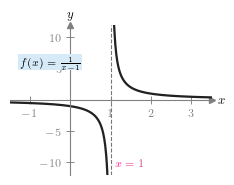

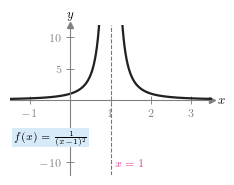

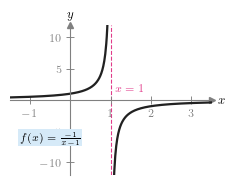

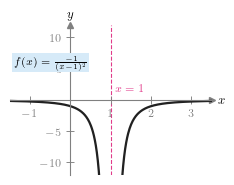

In [62]:
s = 0.65
c = 1.0  # Asymptote location

# Split domain around the asymptote for all graphs
x_left = np.linspace(-1.5, c - 0.05, 200)
x_right = np.linspace(c + 0.05, 3.5, 200)

# ==========================================
# GRAPH 1A: f(x) = 1 / (x - 1)
# ==========================================
fig1, ax1 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax1, x_limits=[-1.5, 3.5], y_limits=[-12, 12], scale=s)
add_textbook_ticks(ax1, x_ticks=[-1, 0, 1, 2, 3], y_ticks=[-10, -5, 5, 10], scale=s)

y1_left = np.clip(1 / (x_left - c), -50, 50)
y1_right = np.clip(1 / (x_right - c), -50, 50)

ax1.plot(x_left, y1_left, color='#212121', linewidth=2.5*s, zorder=2)
ax1.plot(x_right, y1_right, color='#212121', linewidth=2.5*s, zorder=2)

# Asymptote
ax1.axvline(c, color='#E13B8A', linestyle='--', linewidth=1.2*s, zorder=1)
ax1.text(c + 0.1, -11, r'$x=1$', color='#E13B8A', fontsize=12*s, ha='left', va='bottom')


# Function label
add_textbook_label(ax1, x=-0.5, y=6, text=r'$f(x) = \frac{1}{x-1}$', scale=s*0.85)

fig1.savefig("Ch1/inf_limit_1a.pgf", backend="pgf", bbox_inches='tight')


# ==========================================
# GRAPH 1B: f(x) = 1 / (x - 1)^2
# ==========================================
fig2, ax2 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax2, x_limits=[-1.5, 3.5], y_limits=[-12, 12], scale=s)
add_textbook_ticks(ax2, x_ticks=[-1, 0, 1, 2, 3], y_ticks=[-10, -5, 5, 10], scale=s)

y2_left = np.clip(1 / (x_left - c)**2, -50, 50)
y2_right = np.clip(1 / (x_right - c)**2, -50, 50)

ax2.plot(x_left, y2_left, color='#212121', linewidth=2.5*s, zorder=2)
ax2.plot(x_right, y2_right, color='#212121', linewidth=2.5*s, zorder=2)

# Asymptote
ax2.axvline(c, color='#E13B8A', linestyle='--', linewidth=1.2*s, zorder=1)
ax2.text(c + 0.1, -11, r'$x=1$', color='#E13B8A', fontsize=12*s, ha='left', va='bottom')


# Function label
add_textbook_label(ax2, x=-0.5, y=-6, text=r'$f(x) = \frac{1}{(x-1)^2}$', scale=s*0.85)

fig2.savefig("Ch1/inf_limit_1b.pgf", backend="pgf", bbox_inches='tight')

# ==========================================
# GRAPH 1C: f(x) = -1 / (x - 1)
# ==========================================
fig3, ax3 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax3, x_limits=[-1.5, 3.5], y_limits=[-12, 12], scale=s)
add_textbook_ticks(ax3, x_ticks=[-1, 0, 1, 2, 3], y_ticks=[-10, -5, 5, 10], scale=s)

y3_left = np.clip(-1 / (x_left - c), -50, 50)
y3_right = np.clip(-1 / (x_right - c), -50, 50)

ax3.plot(x_left, y3_left, color='#212121', linewidth=2.5*s, zorder=2)
ax3.plot(x_right, y3_right, color='#212121', linewidth=2.5*s, zorder=2)

# Asymptote
ax3.axvline(c, color='#E13B8A', linestyle='--', linewidth=1.2*s, zorder=1)
ax3.text(c + 0.1, 1, r'$x=1$', color='#E13B8A', fontsize=12*s, ha='left', va='bottom')

# Function label
add_textbook_label(ax3, x=-0.5, y=-6, text=r'$f(x) = \frac{-1}{x-1}$', scale=s*0.85)

fig3.savefig("Ch1/inf_limit_1c.pgf", backend="pgf", bbox_inches='tight')

# ==========================================
# GRAPH 1D: f(x) = -1 / (x - 1)^2
# ==========================================
fig4, ax4 = plt.subplots(figsize=(4*s, 3*s))
format_textbook_axes(ax4, x_limits=[-1.5, 3.5], y_limits=[-12, 12], scale=s)
add_textbook_ticks(ax4, x_ticks=[-1, 0, 1, 2, 3], y_ticks=[-10, -5, 5, 10], scale=s)

y4_left = np.clip(-1 / (x_left - c)**2, -50, 50)
y4_right = np.clip(-1 / (x_right - c)**2, -50, 50)

ax4.plot(x_left, y4_left, color='#212121', linewidth=2.5*s, zorder=2)
ax4.plot(x_right, y4_right, color='#212121', linewidth=2.5*s, zorder=2)

# Asymptote
ax4.axvline(c, color='#E13B8A', linestyle='--', linewidth=1.2*s, zorder=1)
ax4.text(c + 0.1, 1, r'$x=1$', color='#E13B8A', fontsize=12*s, ha='left', va='bottom')


# Function label
add_textbook_label(ax4, x=-0.5, y=6, text=r'$f(x) = \frac{-1}{(x-1)^2}$', scale=s*0.85)

fig4.savefig("Ch1/inf_limit_1d.pgf", backend="pgf", bbox_inches='tight')

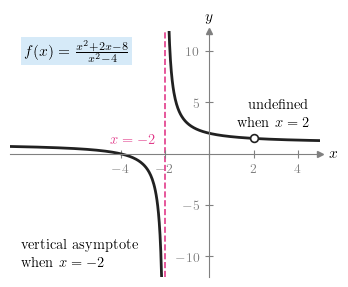

In [63]:
# vertical asymptote at x=-2 for f(X)=(x^2+2x-8)/(x^2-4)
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
# (Assuming format_textbook_axes and add_textbook_ticks are defined elsewhere in your code)
format_textbook_axes(ax, x_limits=[-9, 5], y_limits=[-12, 12], scale=s)
add_textbook_ticks(ax, x_ticks=[-4, -2, 0, 2, 4], y_ticks=[-10, -5, 5, 10], scale=s)

# 3. Plot the math - THREE sections to avoid the asymptotes at x=-2 and x=2
x_left = np.linspace(-9, -2.05, 200)
y_left = np.clip((x_left**2 + 2*x_left - 8) / (x_left**2 - 4), -50, 50)

x_middle = np.linspace(-1.95, 1.95, 200)
y_middle = np.clip((x_middle**2 + 2*x_middle - 8) / (x_middle**2 - 4), -50, 50)

x_right = np.linspace(2.05, 5, 200)
y_right = np.clip((x_right**2 + 2*x_right - 8) / (x_right**2 - 4), -50, 50)

# Plot all three sections
ax.plot(x_left, y_left, color='#212121', linewidth=2.5*s, zorder=2)
ax.plot(x_middle, y_middle, color='#212121', linewidth=2.5*s, zorder=2)
ax.plot(x_right, y_right, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Add vertical asymptotes at x=-2 and x=2
ax.axvline(-2, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# Add the OPEN CIRCLE (hole)
ax.plot(2, 6/4, marker='o', markerfacecolor='white', markeredgecolor='#212121', 
        markersize=7*s, markeredgewidth=1.5*s, zorder=5)

# 5. Add labels 
# Asymptote and Function labels
ax.text(-4.5, 2, r'$x=-2$', color='#E13B8A', fontsize=13*s, ha='left', va='top')
add_textbook_label(ax, x=-6, y=10, text=r'$f(x) = \frac{x^2+2x-8}{x^2-4}$', scale=s)

# FIX: Wrapped in a tabular environment to safely allow line breaks in LaTeX
und_statement = r'\begin{tabular}{r}undefined \\ when $x=2$\end{tabular}'
ax.text(4.5, 4, und_statement, fontsize=13*s, ha='right', va='center')

# FIX: Wrapped in a tabular environment to safely allow line breaks in LaTeX
vertical_asymptote_statement = r'\begin{tabular}{l}vertical asymptote \\ when $x=-2$\end{tabular}'
ax.text(-8.5, -11, vertical_asymptote_statement, fontsize=13*s, ha='left', va='bottom')

# 6. Save and export
fig.savefig("Ch1/vertical_asymptote_xminus2.pgf", backend="pgf", bbox_inches='tight')
plt.show()

C:\Users\Cole\AppData\Local\Temp\ipykernel_6776\3306139077.py:43: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_limits)


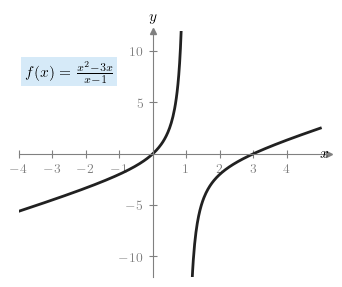

In [64]:
# graph of (x^2-3x)/(x-1)
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
# (Assuming format_textbook_axes and add_textbook_ticks are defined elsewhere in your code)
format_textbook_axes(ax, x_limits=[5, 5], y_limits=[-12, 12], scale=s)
add_textbook_ticks(ax, x_ticks=[-4, -3, -2, -1, 0, 1, 2, 3, 4], y_ticks=[-10, -5, 5, 10], scale=s)

# 3. Plot the math - TWO sections to avoid the asymptote at x=1
x_left = np.linspace(-4, 0.95, 200)
y_left = np.clip((x_left**2 - 3*x_left) / (x_left - 1), -50, 50)

x_right = np.linspace(1.05, 5, 200)
y_right = np.clip((x_right**2 - 3*x_right) / (x_right - 1), -50, 50)

# Plot both sections
ax.plot(x_left, y_left, color='#212121', linewidth=2.5*s, zorder=2)
ax.plot(x_right, y_right, color='#212121', linewidth=2.5*s, zorder=2)

# labels
add_textbook_label(ax, x=-2.5, y=8, text=r'$f(x) = \frac{x^2-3x}{x-1}$', scale=s)

# save and export
fig.savefig("Ch1/vertical_asymptote_xpos1.pgf", backend="pgf", bbox_inches='tight')


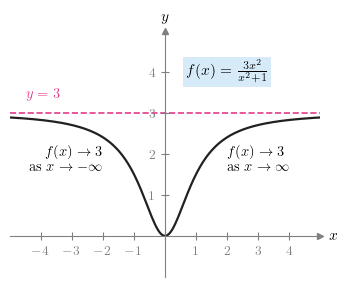

In [65]:
# horizontal asymptote at y=3 for f(X)=(3x^2)/(x^2+1)
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-5, 5], y_limits=[-1, 5], scale=s)
add_textbook_ticks(ax, x_ticks=[-4, -3, -2, -1, 0, 1, 2, 3, 4], y_ticks=[1, 2, 3, 4], scale=s)

# 3. Plot the math 
x = np.linspace(-5, 5, 200)

# Plot the curve
y = (3*x**2) / (x**2 + 1)
ax.plot(x, y, color='#212121', linewidth=2*s, zorder=2)
            
# 4. Add horizontal asymptote at y=3
ax.axhline(3, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# 5. Add labels 
# Asymptote label
ax.text(-4.5, 3.3, r'$y=3$', color='#E13B8A', fontsize=13*s, ha='left', va='bottom')

# Function label
add_textbook_label(ax, x=2, y=4, text=r'$f(x) = \frac{3x^2}{x^2+1}$', scale=s)

# Left behavior
left_inf = r'$f(x) \to 3$' + '\n' + r'as $x \to -\infty$'
ax.text(-2, 1.5, left_inf, fontsize=13*s, ha='right', va='bottom')

# Right behavior
right_inf = r'$f(x) \to 3$' + '\n' + r'as $x \to \infty$'
ax.text(2, 1.5, right_inf, fontsize=13*s, ha='left', va='bottom')

# 6. Save and export
fig.savefig("Ch1/horizontal_asymptote_y3.pgf", backend="pgf", bbox_inches='tight')
plt.show()

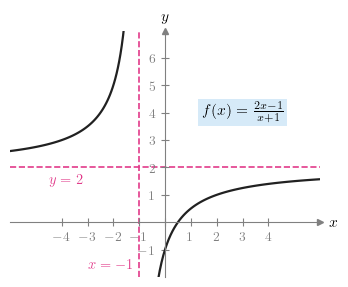

In [66]:
# asymptotes at y=2 and x=-1 for f(x)=(2x-1)/(x+1)
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-6, 6], y_limits=[-2, 7], scale=s)
add_textbook_ticks(ax, x_ticks=[-4, -3, -2, -1, 0, 1, 2, 3, 4], y_ticks=[-1, 1, 2, 3, 4, 5, 6], scale=s)

# 3. Plot the math 
# Create two separate x arrays to avoid the asymptote at x=-1
x_left = np.linspace(-6, -1.02, 100)  # Left side of asymptote
x_right = np.linspace(-0.98, 6, 100)  # Right side of asymptote

# Plot the left curve
y_left = (2*x_left - 1) / (x_left + 1)
ax.plot(x_left, y_left, color='#212121', linewidth=2*s, zorder=2)

# Plot the right curve
y_right = (2*x_right - 1) / (x_right + 1)
ax.plot(x_right, y_right, color='#212121', linewidth=2*s, zorder=2)
            
# 4. Add horizontal asymptote at y=2
ax.axhline(2, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# vertical asymptote at x=-1
ax.axvline(-1, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# 5. Add labels 
# Asymptote label
ax.text(-4.5, 1.3, r'$y=2$', color='#E13B8A', fontsize=13*s, ha='left', va='bottom')
ax.text(-2.1, -1.8, r'$x=-1$', color='#E13B8A', fontsize=13*s, ha='center', va='bottom')

# Function label
add_textbook_label(ax, x=3, y=4, text=r'$f(x) = \frac{2x-1}{x+1}$', scale=s)

# 6. Save and export
fig.savefig("Ch1/vertical_horizontal_y2xminus1.pgf", backend="pgf", bbox_inches='tight')
plt.show()

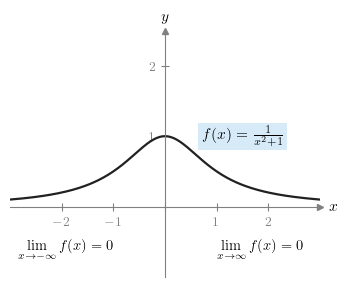

In [67]:
# horizontal asymptote f(x)=1/(x^2+1)
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-3, 3], y_limits=[-1, 2.5], scale=s)
add_textbook_ticks(ax, x_ticks=[-2, -1, 0, 1, 2], y_ticks=[1, 2], scale=s)

# 3. Plot the math 
x = np.linspace(-3, 3, 200)

# Plot the curve
y = 1 / (x**2 + 1)
ax.plot(x, y, color='#212121', linewidth=2*s, zorder=2)

# 4. Add horizontal asymptote at y=0
# ax.axhline(0, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# # 5. Add labels 
# # Asymptote label
# ax.text(-4.5, 3.3, r'$y=0$', color='#E13B8A', fontsize=13*s, ha='left', va='bottom')

# Function label
add_textbook_label(ax, x=1.5, y=1, text=r'$f(x) = \frac{1}{x^2+1}$', scale=s)

# Left behavior
left_inf = r'$\displaystyle \lim_{x \to -\infty} f(x) = 0$'
ax.text(-1, -0.75, left_inf, fontsize=13*s, ha='right', va='bottom')

# Right behavior
right_inf = r'$\displaystyle \lim_{x \to \infty} f(x) = 0$'
ax.text(1, -0.75, right_inf, fontsize=13*s, ha='left', va='bottom')

# 6. Save and export
fig.savefig("Ch1/horizontal_asymptote_y0.pgf", backend="pgf", bbox_inches='tight')
plt.show()

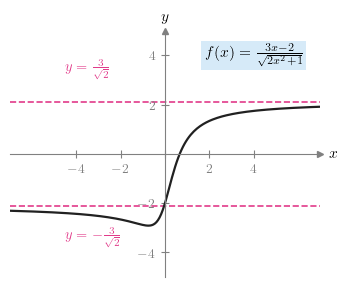

In [68]:
# horizontal asymptote f(x)=(3x-2)/(sqrt(2x^2+1)))
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-7, 7], y_limits=[-5, 5], scale=s)
add_textbook_ticks(ax, x_ticks=[-4, -2, 0, 2, 4], y_ticks=[-4, -2, 2, 4], scale=s)

# 3. Plot the math 
x = np.linspace(-7, 7, 200)

# Plot the curve
y = (3*x - 2) / np.sqrt(2*x**2 + 1)
ax.plot(x, y, color='#212121', linewidth=2*s, zorder=2)

# 4. Add horizontal asymptote at y=3/sqrt(2)
ax.axhline(3/np.sqrt(2), color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)
ax.axhline(-3/np.sqrt(2), color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# 5. Add labels 
# Asymptote label
ax.text(-4.5, 3, r'$y=\frac{3}{\sqrt{2}}$', color='#E13B8A', fontsize=13*s, ha='left', va='bottom')
ax.text(-4.5, -3, r'$y=-\frac{3}{\sqrt{2}}$', color='#E13B8A', fontsize=13*s, ha='left', va='top')

# Function label
add_textbook_label(ax, x=4, y=4, text=r'$f(x) = \frac{3x-2}{\sqrt{2x^2+1}}$', scale=s)

# # Left behavior
# left_inf = r'$\displaystyle \lim_{x \to -\infty} f(x) = 0$'
# ax.text(-1, -0.75, left_inf, fontsize=13*s, ha='right', va='bottom')

# # Right behavior
# right_inf = r'$\displaystyle \lim_{x \to \infty} f(x) = 0$'
# ax.text(1, -0.75, right_inf, fontsize=13*s, ha='left', va='bottom')

# 6. Save and export
fig.savefig("Ch1/irrational_asymptote.pgf", backend="pgf", bbox_inches='tight')
plt.show()

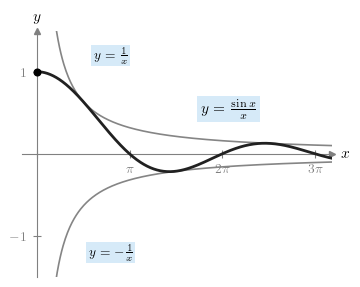

In [69]:
# sin(x)/x squeezed between y=1/x and y=-1/x
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-0.5, 10], y_limits=[-1.5, 1.5], scale=s)
# Provide nice math labels for the pi ticks
pi_ticks = [0, np.pi, 2*np.pi, 3*np.pi]
pi_labels = [r'$0$', r'$\pi$', r'$2\pi$', r'$3\pi$']
add_textbook_ticks(ax, x_ticks=pi_ticks, y_ticks=[-1, 1], x_labels=pi_labels, scale=s)

# 3. Plot the sinc-like curve safely (define value 1 at x=0)
x = np.linspace(0.01, 10, 800)
y = np.where(np.isclose(x, 0.0), 1.0, np.sin(x) / x)
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=3)

# 4. Plot the envelope functions y=1/x and y=-1/x (positive x only)
x_pos = np.linspace(0.1, 10, 400)
ax.plot(x_pos, 1/ x_pos, color="#858585", linestyle='-', linewidth=1.5*s, zorder=2)
ax.plot(x_pos, -1/ x_pos, color='#858585', linestyle='-', linewidth=1.5*s, zorder=2)

# 5. Mark the limiting value at the origin and annotate
ax.plot(0, 1, marker='o', color='black', markersize=6*s, zorder=5)
#ax.text(0.25, 1.05, '$(0,1)$', fontsize=12*s, fontstyle='italic')

# 6. Add textbook labels for clarity
add_textbook_label(ax, x=6.5, y=0.55, text=r'$y=\frac{\sin x}{x}$', scale=s)
add_textbook_label(ax, x=2.5, y=1.2, text=r'$y=\frac{1}{x}$', scale=s*0.85)
add_textbook_label(ax, x=2.5, y=-1.2, text=r'$y=-\frac{1}{x}$', scale=s*0.85)

# 7. Save and export
fig.savefig("Ch1/sinc_squeeze.pgf", backend="pgf", bbox_inches='tight')
plt.show()


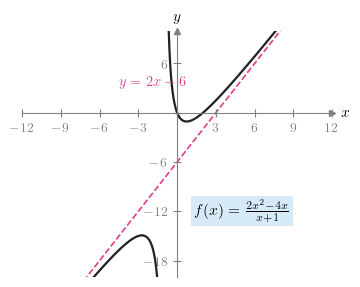

In [70]:
# slant asymptote of f(x) = (2x^2-4x)/(x+1)
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-12, 12], y_limits=[-20, 10], scale=s)
add_textbook_ticks(ax, x_ticks=[-12, -9, -6, -3, 0, 3, 6, 9, 12], y_ticks=[-18, -12, -6, 0, 6], scale=s)

# 3. Plot the math 
x = np.linspace(-12, 12, 200)
x_neg = np.linspace(-12, -1.01, 200)
x_pos = np.linspace(-0.99, 12, 200)

# Plot the curve
y_neg = (2*x_neg**2 - 4*x_neg) / (x_neg + 1)
y_pos = (2*x_pos**2 - 4*x_pos) / (x_pos + 1)
ax.plot(x_neg, y_neg, color='#212121', linewidth=2*s, zorder=2)
ax.plot(x_pos, y_pos, color='#212121', linewidth=2*s, zorder=2)

# 4. Add slant asymptote at y=2x-6
ax.plot(x, 2*x - 6, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# 5. Add labels 
# Asymptote label
ax.text(-4.5, 3, r'$y=2x-6$', color='#E13B8A', fontsize=13*s, ha='left', va='bottom')

# Function label
add_textbook_label(ax, x=5, y=-12, text=r'$f(x) = \frac{2x^2-4x}{x+1}$', scale=s)


# 6. Save and export
fig.savefig("Ch1/slant_asymptote.pgf", backend="pgf", bbox_inches='tight')
plt.show()

## Chapter 2

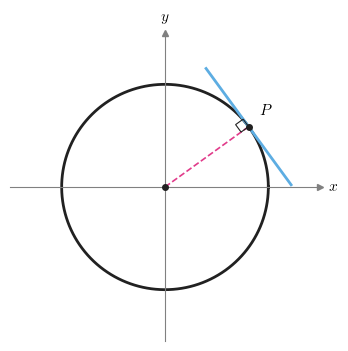

In [71]:
s = 0.8

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 5*s))

# 2. Apply textbook formatting
format_textbook_axes(ax, x_limits=[-6, 6], y_limits=[-6, 6], scale=s)
# add_textbook_ticks(ax, x_ticks=[-4, -2, 2, 4], y_ticks=[-4, -2, 2, 4], scale=s)

# 3. Define the circle
r = 4
theta_P = np.pi / 5  # 45°, the "top right" edge of the circle

theta = np.linspace(0, 2*np.pi, 300)
x_circle = r * np.cos(theta)
y_circle = r * np.sin(theta)
ax.plot(x_circle, y_circle, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Key points
center = np.array([0, 0])
P = np.array([r*np.cos(theta_P), r*np.sin(theta_P)])

# Unit vector pointing from P toward the center (the radius direction)
u_radial = (center - P) / np.linalg.norm(center - P)
# Unit vector along the tangent line (perpendicular to the radius)
u_tangent = np.array([-np.sin(theta_P), np.cos(theta_P)])

# 5. Tangent line (solid blue), extended past the circle on both sides
t_len = 2.8
tangent_start = P - t_len * u_tangent
tangent_end   = P + t_len * u_tangent
ax.plot([tangent_start[0], tangent_end[0]],
        [tangent_start[1], tangent_end[1]],
        color='#5DADE2', linewidth=2.5*s, zorder=2)

# 6. Radius line: pink dashed, from center to P
ax.plot([center[0], P[0]], [center[1], P[1]],
        color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# 7. Right-angle marker at P (small square between radius and tangent)
sq = 0.45 * s
corner1 = P + sq * u_radial
corner2 = corner1 + sq * u_tangent
corner3 = P + sq * u_tangent
right_angle = plt.Polygon([P, corner1, corner2, corner3],
                           closed=True, facecolor='none',
                           edgecolor='#212121', linewidth=1*s, zorder=3)
ax.add_patch(right_angle)

# 8. Center point (unlabeled) and point P (labeled)
ax.plot(*center, marker='o', markersize=5*s, color='#212121', zorder=4)
ax.plot(*P, marker='o', markersize=5*s, color='#212121', zorder=4)

# Offset the "P" label radially outward so it doesn't sit on the point
label_offset = 0.55
P_label_pos = P + label_offset * (P / r)
ax.text(P_label_pos[0], P_label_pos[1], r'$P$',
        fontsize=14*s, ha='left', va='bottom')

# 9. Save and export
fig.savefig("Ch2/circle_tangent_line.pgf", backend="pgf", bbox_inches='tight')
plt.show()

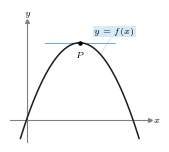

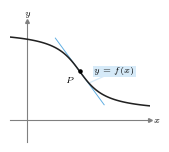

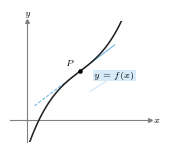

In [72]:
s = 0.45 # Smaller scale to fit 3 graphs side-by-side
blue_color = '#5DADE2'
black_color = '#212121'

# ==========================================
# GRAPH 1: Horizontal Tangent
# ==========================================
fig1, ax1 = plt.subplots(figsize=(4*s, 3.5*s))
format_textbook_axes(ax1, x_limits=[-0.5, 3.5], y_limits=[-1, 4.5], scale=s)

x1 = np.linspace(-0.2, 3.2, 100)
y1 = -1.5 * (x1 - 1.5)**2 + 3.5

# Tangent line and curve
ax1.plot([0.5, 2.5], [3.5, 3.5], color=blue_color, linewidth=1.5*s, zorder=2)
ax1.plot(x1, y1, color=black_color, linewidth=2.5*s, zorder=3)

# Point P
ax1.plot(1.5, 3.5, marker='o', color='black', markersize=5*s, zorder=4)
ax1.text(1.5, 3.1, '$P$', fontsize=14*s, fontstyle='italic', ha='center', va='top')

# Label and pointer line
ax1.plot([2.5, 2.1], [4.0, 3.0], color='#D6EAF8', linewidth=2*s, zorder=1)
add_textbook_label(ax1, x=2.5, y=4.0, text='$y=f(x)$', scale=s)

fig1.savefig("Ch2/tangent_horizontal.pgf", backend="pgf", bbox_inches='tight')

# ==========================================
# GRAPH 2: Tangent on Decreasing Curve
# ==========================================
fig2, ax2 = plt.subplots(figsize=(4*s, 3.5*s))
format_textbook_axes(ax2, x_limits=[-0.5, 3.5], y_limits=[-1, 4.5], scale=s)

x2 = np.linspace(-0.5, 3.5, 100)
y2 = -1.2 * np.arctan(1.8 * (x2 - 1.5)) + 2.2

# Tangent line and curve
# Derivative of -1.2*arctan(1.8*x) evaluated at 0 is -1.2 * 1.8 = -2.16
m2 = -2.16
x_tan2 = np.linspace(0.8, 2.2, 20)
y_tan2 = m2 * (x_tan2 - 1.5) + 2.2

ax2.plot(x_tan2, y_tan2, color=blue_color, linewidth=1.5*s, zorder=2)
ax2.plot(x2, y2, color=black_color, linewidth=2.5*s, zorder=3)

# Point P
ax2.plot(1.5, 2.2, marker='o', color='black', markersize=5*s, zorder=4)
ax2.text(1.3, 2.0, '$P$', fontsize=14*s, fontstyle='italic', ha='right', va='top')

# Label and pointer line
ax2.plot([2.5, 1.8], [2.2, 1.7], color='#D6EAF8', linewidth=2*s, zorder=1)
add_textbook_label(ax2, x=2.5, y=2.2, text='$y=f(x)$', scale=s)

fig2.savefig("Ch2/tangent_decreasing.pgf", backend="pgf", bbox_inches='tight')

# ==========================================
# GRAPH 3: Inflection Point Tangent (Solid/Dashed)
# ==========================================
fig3, ax3 = plt.subplots(figsize=(4*s, 3.5*s))
format_textbook_axes(ax3, x_limits=[-0.5, 3.5], y_limits=[-1, 4.5], scale=s)

x3 = np.linspace(-0.5, 3.5, 100)
y3 = 0.5 * (x3 - 1.5)**3 + 1.2 * (x3 - 1.5) + 2.2

# Tangent line (Dashed below P, Solid above P)
m3 = 1.2 # Derivative at inflection point (x=1.5)
x_tan3_dashed = np.linspace(0.2, 1.5, 20)
y_tan3_dashed = m3 * (x_tan3_dashed - 1.5) + 2.2

x_tan3_solid = np.linspace(1.5, 2.5, 20)
y_tan3_solid = m3 * (x_tan3_solid - 1.5) + 2.2

ax3.plot(x_tan3_dashed, y_tan3_dashed, color=blue_color, linewidth=1.5*s, linestyle='--', zorder=2)
ax3.plot(x_tan3_solid, y_tan3_solid, color=blue_color, linewidth=1.5*s, linestyle='-', zorder=2)
ax3.plot(x3, y3, color=black_color, linewidth=2.5*s, zorder=3)

# Point P
ax3.plot(1.5, 2.2, marker='o', color='black', markersize=5*s, zorder=4)
ax3.text(1.3, 2.4, '$P$', fontsize=14*s, fontstyle='italic', ha='right', va='bottom')

# Label and pointer line
ax3.plot([2.5, 1.8], [2.0, 1.3], color='#D6EAF8', linewidth=2*s, zorder=1)
add_textbook_label(ax3, x=2.5, y=2.0, text='$y=f(x)$', scale=s)

fig3.savefig("Ch2/tangent_inflection.pgf", backend="pgf", bbox_inches='tight')

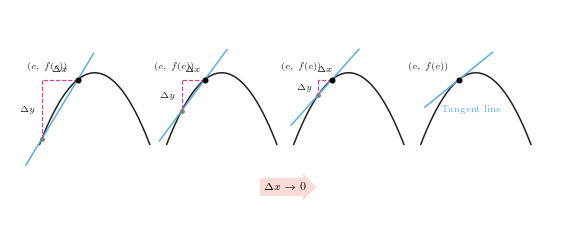

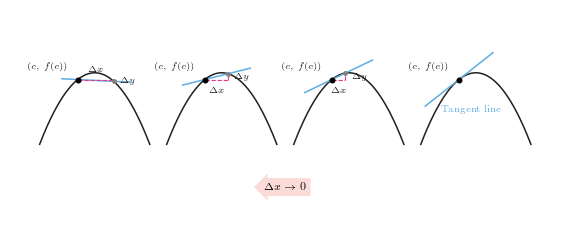

In [73]:
def local_curve(t):
    """Generic 'hill' shape reused for every secant/tangent panel."""
    return 1.0 - t**2

def draw_secant_panel(ax, X0, Y0, dx, side='left',
                       scale=1.0,
                       curve_color='#212121',
                       secant_color='#5DADE2',
                       dash_color='#E13B8A',
                       label_color='#212121',
                       c_t=-0.4,
                       show_tangent_label=False,
                       fs=12):
    
    lw = 2.0 * scale
    size = 1.0 # Locked size to ensure all panels are identical dimensions

    # --- the curve itself ---
    t_curve = np.linspace(-1.3, 1.3, 200)
    x_curve = X0 + size * t_curve
    y_curve = Y0 + size * local_curve(t_curve)
    ax.plot(x_curve, y_curve, color=curve_color, linewidth=lw, zorder=2)

    # --- point c and the moving secant point ---
    xc, yc = X0 + size * c_t, Y0 + size * local_curve(c_t)
    t2 = c_t - dx if side == 'left' else c_t + dx
    x2, y2 = X0 + size * t2, Y0 + size * local_curve(t2)

    # --- secant/tangent line, centered on the two points and extended ---
    slope = (y2 - yc) / (x2 - xc)
    xm, ym = (xc + x2) / 2, (yc + y2) / 2
    x_ext = 0.8 * size
    line_x = np.array([xm - x_ext, xm + x_ext])
    line_y = ym + slope * (line_x - xm)
    ax.plot(line_x, line_y, color=secant_color, linewidth=lw, zorder=3)

    # --- Δx / Δy construction triangle (dashed pink) ---
    if not show_tangent_label:
        ax.plot([xc, x2], [yc, yc], color=dash_color, linestyle='--', linewidth=1.5*scale, zorder=4)
        ax.plot([x2, x2], [yc, y2], color=dash_color, linestyle='--', linewidth=1.5*scale, zorder=4)

        # DYNAMIC PLACEMENT: Ensure labels are strictly OUTSIDE the triangle
        dy_dir = -1 if y2 > yc else 1
        yc_label = yc + dy_dir * 0.15 * size
        va_x = 'top' if dy_dir == -1 else 'bottom'

        dx_dir = 1 if x2 > xc else -1
        x2_label = x2 + dx_dir * 0.15 * size
        ha_y = 'left' if dx_dir == 1 else 'right'

        ax.text((xc + x2)/2, yc_label, r'$\Delta x$', color=label_color,
                fontsize=fs*scale, ha='center', va=va_x, fontstyle='italic')
        ax.text(x2_label, (yc + y2)/2, r'$\Delta y$', color=label_color,
                fontsize=fs*scale, ha=ha_y, va='center', fontstyle='italic')

        # --- moving point ---
        ax.plot(x2, y2, marker='o', markersize=4.5*scale, color='gray', zorder=5)

    # --- P(c, f(c)) fixed point ---
    ax.plot(xc, yc, marker='o', markersize=6*scale, color='black', zorder=6)

    # --- P label safely placed on the outside top-left ---
    ax.text(xc - 0.2*size, yc + 0.2*size, r'$(c,\,f(c))$', color=label_color,
            fontsize=fs*scale, ha='right', va='bottom')

    # Tangent specific label
    if show_tangent_label:
        ax.text(xc + 0.3*size, yc - 0.6*size, 'Tangent line',
                color=secant_color, fontsize=fs*scale, ha='center', va='top', weight='bold')


s = 0.55 
# We can use the same X positions for both graphs since they are on separate canvases now
positions = [2.0, 5.0, 8.0, 11.0]

# =====================================================================
# FIGURE 1: Approaching from the Left
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(14*s, 5*s))
ax1.set_xlim(0, 13)
ax1.set_ylim(0, 5)
ax1.set_aspect('equal')
ax1.axis('off')

left_dx = [0.85, 0.55, 0.32, 0.01]

for i, (X0, dx) in enumerate(zip(positions, left_dx)):
    draw_secant_panel(ax1, X0, 2.5, dx, side='left', scale=s,
                       show_tangent_label=(i == len(positions) - 1))

# Left transition arrow (points right)
ax1.text(6.5, 0.8, r'$\Delta x \to 0$', fontsize=14*s, ha='center', va='center',
         bbox=dict(boxstyle="rarrow,pad=0.4", fc='#FADBD8', ec='none'))

fig1.savefig("Ch2/tangent_approx_left.pgf", backend="pgf", bbox_inches='tight')

# =====================================================================
# FIGURE 2: Approaching from the Right
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(14*s, 5*s))
ax2.set_xlim(0, 13)
ax2.set_ylim(0, 5)
ax2.set_aspect('equal')
ax2.axis('off')

right_dx = [0.85, 0.55, 0.32, 0.01]

for i, (X0, dx) in enumerate(zip(positions, right_dx)):
    draw_secant_panel(ax2, X0, 2.5, dx, side='right', scale=s,
                       show_tangent_label=(i == len(positions) - 1))

# Right transition arrow (points left)
ax2.text(6.5, 0.8, r'$\Delta x \to 0$', fontsize=14*s, ha='center', va='center',
         bbox=dict(boxstyle="larrow,pad=0.4", fc='#FADBD8', ec='none'))

fig2.savefig("Ch2/tangent_approx_right.pgf", backend="pgf", bbox_inches='tight')

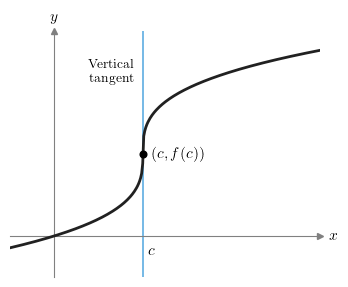

In [74]:
# vertical tangent line (x-1)^(1/3) + 1

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(5*s, 4*s))

# 2. Apply your custom textbook formatting
# Tightened the limits so the curve perfectly fills the frame without dead space
format_textbook_axes(ax, x_limits=[-0.5, 3], y_limits=[-0.5, 2.5], scale=s)
# add_textbook_ticks(ax, x_ticks=[0, 1, 2], y_ticks=[1, 2], scale=s)

# 3. Plot the math
x = np.linspace(-0.5, 3, 300)
y = np.cbrt(x - 1) + 1

# Draw the vertical tangent line at x=1 FIRST so it sits behind the curve
ax.plot([1, 1], [-0.5, 2.5], color='#5DADE2', linewidth=1.5*s, zorder=2)

# Draw the main line
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=3)

# 4. Add the point of tangency
ax.plot(1, 1, marker='o', color='black', markersize=6*s, zorder=5)

# 5. Add Labels
# Point P label
ax.text(1.1, 1.1, '$(c, f(c))$', fontsize=14*s, fontstyle='italic', ha='left', va='top')

# Tangent line label
ax.text(0.9, 2.0, 'Vertical \n tangent', color="#000000", 
        fontsize=12*s, ha='right', va='center', weight='bold')

# label c on axis
ax.text(1.1, -0.1, '$c$', fontsize=14*s, ha='center', va='top')

# 6. Save and export
fig.savefig("Ch2/vertical_tangent_line.pgf", backend="pgf", bbox_inches='tight')
plt.show()

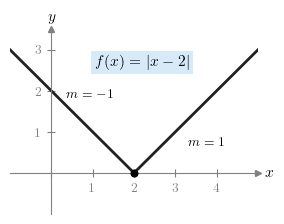

In [86]:
# limit of +x-2+ as x->2

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-1, 5], y_limits=[-1, 3.5], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[0, 1, 2, 3, 4], y_ticks=[1, 2, 3], scale=s)

# 3. Plot the math
x = np.linspace(-1, 5, 200)
y = np.abs(x-2)

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# # Add the OPEN CIRCLE (hole)
# ax.plot(1, 3, marker='o', markerfacecolor='white', markeredgecolor='#212121', 
#         markersize=7*s, markeredgewidth=1.5*s, zorder=5)
        
# ax.text(-1.8, 3.2, '$(-2, 2)$', fontsize=14*s, fontstyle='italic')

# 4. Use your label function
add_textbook_label(ax, x=2.2, y=2.7, text='$f(x) = |x-2|$', scale=s)
ax.text(1.5, 1.9, s='$m = -1$', color="#000000", 
        fontsize=12*s, ha='right', va='center', weight='bold')
ax.text(3.3, 0.75, s='$m = 1$', color="#000000", 
        fontsize=12*s, ha='left', va='center', weight='bold')


# add a point at (2,0) to indicate the limit
ax.plot(2, 0, marker='o', color='black', markersize=6*s, zorder=5)

# 5. Save and export
fig.savefig("Ch2/limit_of_abs.pgf", backend="pgf", bbox_inches='tight')

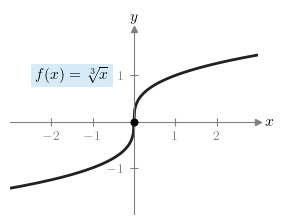

In [93]:
# vertical tangent of x^(1/3)
s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-3, 3], y_limits=[-2, 2], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-2, -1, 0, 1, 2], y_ticks=[-1, 1], scale=s)

# 3. Plot the math
x = np.linspace(-3, 3, 200)
y = np.cbrt(x)

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Use your label function
add_textbook_label(ax, x=-1.5, y=1, text='$f(x) = \sqrt[3]{x}$', scale=s)

# add a point at (0,0) to indicate the limit
ax.plot(0, 0, marker='o', color='black', markersize=6*s, zorder=5)

# 5. Save and export
fig.savefig("Ch2/vertical_tangent_line2.pgf", backend="pgf", bbox_inches='tight')
plt.show()

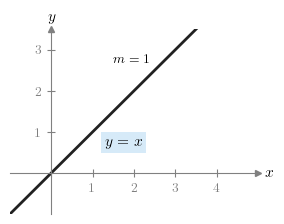

In [101]:
# line y=x

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-1, 5], y_limits=[-1, 3.5], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[0, 1, 2, 3, 4], y_ticks=[1, 2, 3], scale=s)

# 3. Plot the math
x = np.linspace(-1, 5, 200)
y = x

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Use your label function
add_textbook_label(ax, x=1.75, y=0.75, text='$y=x$', scale=s)
ax.text(1.5, 2.75, s='$m = 1$', color="#000000", 
        fontsize=12*s, ha='left', va='center', weight='bold')

# 5. Save and export
fig.savefig("Ch2/yx.pgf", backend="pgf", bbox_inches='tight')

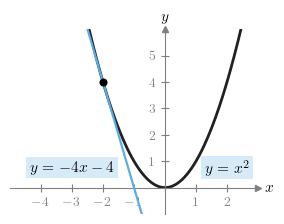

In [111]:
# graph of f(x)=x^2 with tangent line at x=-2

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
# Extended x_limits to 3.5 so the axis is long enough to hold the '3' tick mark
format_textbook_axes(ax, x_limits=[-5, 3], y_limits=[-1, 6], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-4, -3, -2, -1, 0, 1, 2], y_ticks=[1, 2, 3, 4, 5], scale=s)

# 3. Plot the math
x = np.linspace(-5, 3, 200)
y = x**2

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Use your label function
add_textbook_label(ax, x=2, y=0.75, text='$y=x^2$', scale=s)

# add a point at (-2,4) to indicate the tangent point
ax.plot(-2, 4, marker='o', color='black', markersize=6*s, zorder=5)

# add the tangent line at x=-2
x_tan = np.linspace(-3, 0, 200)
y_tan = -4 * (x_tan + 2) + 4
ax.plot(x_tan, y_tan, color='#5DADE2', linewidth=2*s, zorder=3)
add_textbook_label(ax, x=-3, y=0.75, text='$y=-4x-4$', scale=s)

# Save and export
fig.savefig("Ch2/yx2.pgf", backend="pgf", bbox_inches='tight')

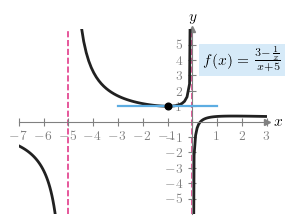

In [16]:
# graph of f(x)=(3-1/x)/(x+5) with tangent line at x=-1

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
format_textbook_axes(ax, x_limits=[-7, 3], y_limits=[-6, 6], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3], y_ticks=[-5, -4, -3, -2, -1, 1, 2, 3, 4, 5], scale=s)

# 3. Plot the math in three steps to avoid the vertical asymptote at x=0 and x=-5
x1 = np.linspace(-7, -5.01, 50)
y = (3 - 1/x1) / (x1 + 5)

x2 = np.linspace(-4.99, -0.01, 50)
y2 = (3 - 1/x2) / (x2 + 5)

x3 = np.linspace(0.01, 3, 50)
y3 = (3 - 1/x3) / (x3 + 5)

# Draw the main line 
ax.plot(x1, y, color='#212121', linewidth=2.5*s, zorder=2)
ax.plot(x2, y2, color='#212121', linewidth=2.5*s, zorder=2)
ax.plot(x3, y3, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Use your label function
add_textbook_label(ax, x=2, y=4, text=r'$f(x) = \frac{3-\frac{1}{x}}{x+5}$', scale=s)

# add a point at (-1,1) to indicate the tangent point
ax.plot(-1, 1, marker='o', color='black', markersize=6*s, zorder=5)

# horizontal tangent line at x=-1
x_tan = np.linspace(-3, 1, 200)
y_tan = np.full_like(x_tan, 1)
ax.plot(x_tan, y_tan, color='#5DADE2', linewidth=2*s, zorder=3)

# verical lines at the two asymptotes x=0 and x=-5
ax.axvline(0, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)
ax.axvline(-5, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# Save and export
fig.savefig("Ch2/fract_tang.pgf", backend="pgf", bbox_inches='tight')

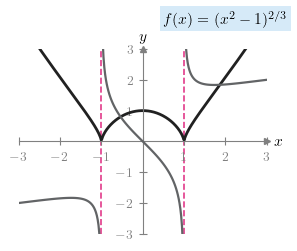

In [22]:
# graph of f(x)= (x^2-1)^{2/3} with tangent line at x=1 and x=-1

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
format_textbook_axes(ax, x_limits=[-3, 3], y_limits=[-3, 3], scale=s)

# Removed the '4' tick, as the curve exits the top of the graph rapidly anyway
add_textbook_ticks(ax, x_ticks=[-3, -2, -1, 0, 1, 2, 3], y_ticks=[-3, -2, -1, 1, 2, 3], scale=s)

# 3. Plot the main function in ONE segment 
# np.cbrt safely handles the cube root of the squared (positive) values
x_main = np.linspace(-3, 3, 500)
y_main = np.cbrt((x_main**2 - 1)**2)

# Draw the main curve
ax.plot(x_main, y_main, color='#212121', linewidth=2.5*s, zorder=2)

# ... [Keep your label function] ...

# Vertical tangent lines at x=1 and x=-1
ax.axvline(1, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)
ax.axvline(-1, color='#E13B8A', linestyle='--', linewidth=1.5*s, zorder=1)

# 5. Plot the derivative f'(x) = (4/3)x / (x^2-1)^(1/3)
# We split this into three segments to avoid drawing lines across the vertical asymptotes.
# Using np.cbrt() fixes the negative base issue inside (-1, 1).

x_der1 = np.linspace(-3, -1.01, 100)
y_der1 = (4/3) * x_der1 / np.cbrt(x_der1**2 - 1)

x_der2 = np.linspace(-0.99, 0.99, 100)
y_der2 = (4/3) * x_der2 / np.cbrt(x_der2**2 - 1)

x_der3 = np.linspace(1.01, 3, 100)
y_der3 = (4/3) * x_der3 / np.cbrt(x_der3**2 - 1)

# Draw the derivative
ax.plot(x_der1, y_der1, color="#626466", linewidth=2*s, zorder=3)
ax.plot(x_der2, y_der2, color="#626466", linewidth=2*s, zorder=3)
ax.plot(x_der3, y_der3, color="#626466", linewidth=2*s, zorder=3)


add_textbook_label(ax, x=2, y=4, text=r'$f(x) = (x^2-1)^{2/3}$', scale=s)
# Save and export
fig.savefig("Ch2/chain_radical.pgf", backend="pgf", bbox_inches='tight')

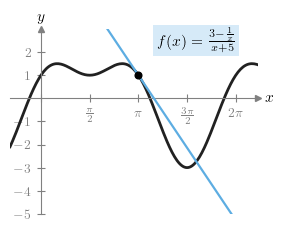

In [9]:
# graph of f(x)= 2 sin(x) + cos (2x) with tangent line at x= pi

s = 0.8 

# 1. Create a blank canvas
fig, ax = plt.subplots(figsize=(4*s, 3*s))

# 2. Apply textbook formatting 
format_textbook_axes(ax, x_limits=[-1, 7], y_limits=[-5, 3], scale=s)

# Define the numerical locations for the ticks using numpy
x_tick_positions = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

# Define the corresponding symbolic LaTeX labels
x_tick_labels = ['$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']

# Apply the ticks and labels
add_textbook_ticks(
    ax, 
    x_ticks=x_tick_positions, 
    x_labels=x_tick_labels, 
    y_ticks=[-5, -4, -3, -2, -1, 1, 2], 
    scale=s
)

# 3. Plot the math in three steps to avoid the vertical asymptote at x=0 and x=-5
x = np.linspace(-1, 7, 200)
y = 2 * np.sin(x) + np.cos(2*x)

# Draw the main line 
ax.plot(x, y, color='#212121', linewidth=2.5*s, zorder=2)

# 4. Use your label function
add_textbook_label(ax, x=5, y=2.5, text=r'$f(x) = \frac{3-\frac{1}{x}}{x+5}$', scale=s)

# add a point at (-1,1) to indicate the tangent point
ax.plot(np.pi, 1, marker='o', color='black', markersize=6*s, zorder=5)

# horizontal tangent line at x= pi
x_tan = np.linspace(1.5, 7, 100)
y_tan = 1 - 2*x_tan + 2*np.pi
ax.plot(x_tan, y_tan, color='#5DADE2', linewidth=2*s, zorder=3)

# Save and export
fig.savefig("Ch2/trig_tang_line.pgf", backend="pgf", bbox_inches='tight')